In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Your boiler data from simulation
df = pd.DataFrame({
    'Load (%)': [60, 70, 80, 90, 100],
    'Excess Air (%)': [40, 50, 60, 65, 70],
    'Air Flow Rate (kg/hr)': [10214, 12585, 15175, 17455, 19845],
    'O2 in Flue Gas (%)': [6.00, 7.00, 7.88, 8.27, 8.65],
    'Heat Generation (W)': [3034050, 3488158, 3942265, 4396373, 4850481],
    'Heat Loss (W)': [205910, 264311, 327809, 377581, 430066],
    'Combustion Efficiency (%)': [93.2, 92.4, 91.7, 91.4, 91.1]
})

print("Dataset:")
df

Dataset:


,Load (%),Excess Air (%),Air Flow Rate (kg/hr),O2 in Flue Gas (%),Heat Generation (W),Heat Loss (W),Combustion Efficiency (%)
0,60,40,10214,6.00,3034050,205910,93.2
1,70,50,12585,7.00,3488158,264311,92.4
2,80,60,15175,7.88,3942265,327809,91.7
3,90,65,17455,8.27,4396373,377581,91.4
4,100,70,19845,8.65,4850481,430066,91.1


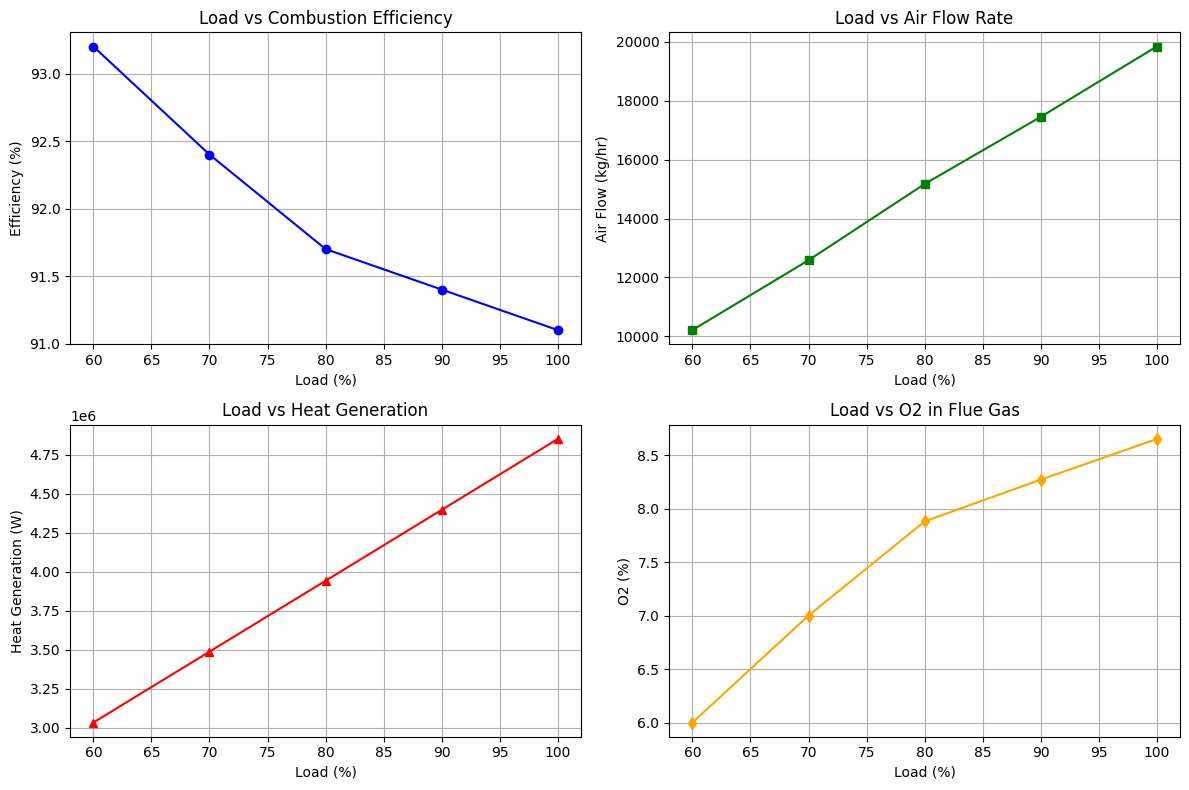

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(df['Load (%)'], df['Combustion Efficiency (%)'], 
               marker='o', color='blue')
axes[0,0].set_title('Load vs Combustion Efficiency')
axes[0,0].set_xlabel('Load (%)')
axes[0,0].set_ylabel('Efficiency (%)')
axes[0,0].grid(True)

axes[0,1].plot(df['Load (%)'], df['Air Flow Rate (kg/hr)'], 
               marker='s', color='green')
axes[0,1].set_title('Load vs Air Flow Rate')
axes[0,1].set_xlabel('Load (%)')
axes[0,1].set_ylabel('Air Flow (kg/hr)')
axes[0,1].grid(True)

axes[1,0].plot(df['Load (%)'], df['Heat Generation (W)'], 
               marker='^', color='red')
axes[1,0].set_title('Load vs Heat Generation')
axes[1,0].set_xlabel('Load (%)')
axes[1,0].set_ylabel('Heat Generation (W)')
axes[1,0].grid(True)

axes[1,1].plot(df['Load (%)'], df['O2 in Flue Gas (%)'], 
               marker='d', color='orange')
axes[1,1].set_title('Load vs O2 in Flue Gas')
axes[1,1].set_xlabel('Load (%)')
axes[1,1].set_ylabel('O2 (%)')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

In [3]:
# Features and target
X = df[['Load (%)', 'Excess Air (%)', 'Air Flow Rate (kg/hr)', 'O2 in Flue Gas (%)']]
y = df['Combustion Efficiency (%)']

# Train model (using all data - small dataset)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}%")
print("\nPredicted vs Actual:")
results = pd.DataFrame({'Actual': y, 'Predicted': y_pred.round(2)})
print(results)

R2 Score: 0.9626
RMSE: 0.1460%

Predicted vs Actual:
   Actual  Predicted
0    93.2      92.92
1    92.4      92.47
2    91.7      91.73
3    91.4      91.41
4    91.1      91.24


C:\Users\smrity\AppData\Local\Temp\ipykernel_22700\3864336418.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')


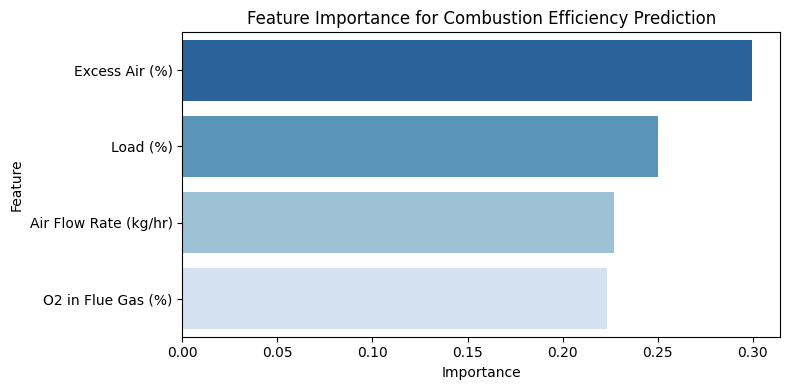

                 Feature  Importance
1         Excess Air (%)    0.299330
0               Load (%)    0.250396
2  Air Flow Rate (kg/hr)    0.226794
3     O2 in Flue Gas (%)    0.223479


In [4]:
feature_names = X.columns
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance for Combustion Efficiency Prediction')
plt.tight_layout()
plt.show()

print(feat_imp)

C:\Users\smrity\Documents\GitHub\Analysis-of-Rice-straw-Boiler\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\smrity\Documents\GitHub\Analysis-of-Rice-straw-Boiler\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\smrity\Documents\GitHub\Analysis-of-Rice-straw-Boiler\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\smrity\Documents\GitHub\Analysis-of-Rice-straw-Boiler\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\smrity\Documents\Gi

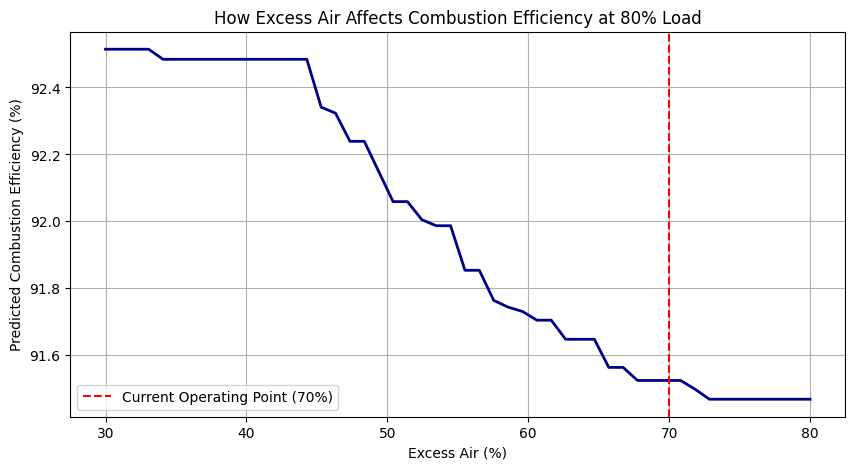

Optimal Excess Air for maximum efficiency: 30.0%
Predicted max efficiency: 92.51%


In [5]:
# What if we change excess air from 30% to 80%?
excess_air_range = np.linspace(30, 80, 50)
load_fixed = 80  # fixed at 80% load

# Estimate air flow and O2 based on excess air
stoich_afr = 3.6479
fuel_at_80 = 2600  # kg/hr

predictions = []
for ea in excess_air_range:
    afr = stoich_afr * (1 + ea/100)
    air_flow = afr * fuel_at_80
    o2 = ea / (ea + 100) * 21
    pred = model.predict([[load_fixed, ea, air_flow, o2]])[0]
    predictions.append(pred)

plt.figure(figsize=(10, 5))
plt.plot(excess_air_range, predictions, color='darkblue', linewidth=2)
plt.axvline(x=70, color='red', linestyle='--', label='Current Operating Point (70%)')
plt.xlabel('Excess Air (%)')
plt.ylabel('Predicted Combustion Efficiency (%)')
plt.title('How Excess Air Affects Combustion Efficiency at 80% Load')
plt.legend()
plt.grid(True)
plt.show()

optimal_ea = excess_air_range[np.argmax(predictions)]
print(f"Optimal Excess Air for maximum efficiency: {optimal_ea:.1f}%")
print(f"Predicted max efficiency: {max(predictions):.2f}%")